# Brain Tumor MRI

## Setting

In [1]:
import os
import sys
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
sys.path.append(os.getcwd())

In [3]:
from model.simple_cnn import SimpleCNN
from model.resnet18 import get_resnet18
from model.efficientnet import get_efficientnet_b0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA RTX A6000


## Parameters

In [4]:
train_dir = "data/Training"
test_dir = "data/Testing"

img_size = 224
batch_size = 32
num_classes = 4
lr = 1e-3
num_epochs = 20
val_ratio = 0.2
random_seed = 42

## Data Loading

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

print("Classes:", full_train_dataset.classes)
print("Class to idx:", full_train_dataset.class_to_idx)
print("Full training data size:", len(full_train_dataset))
print("Testing data size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to idx: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Full training data size: 5600
Testing data size: 1600


In [6]:
train_size = int((1 - val_ratio) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(random_seed)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 4480
Val size: 1120


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

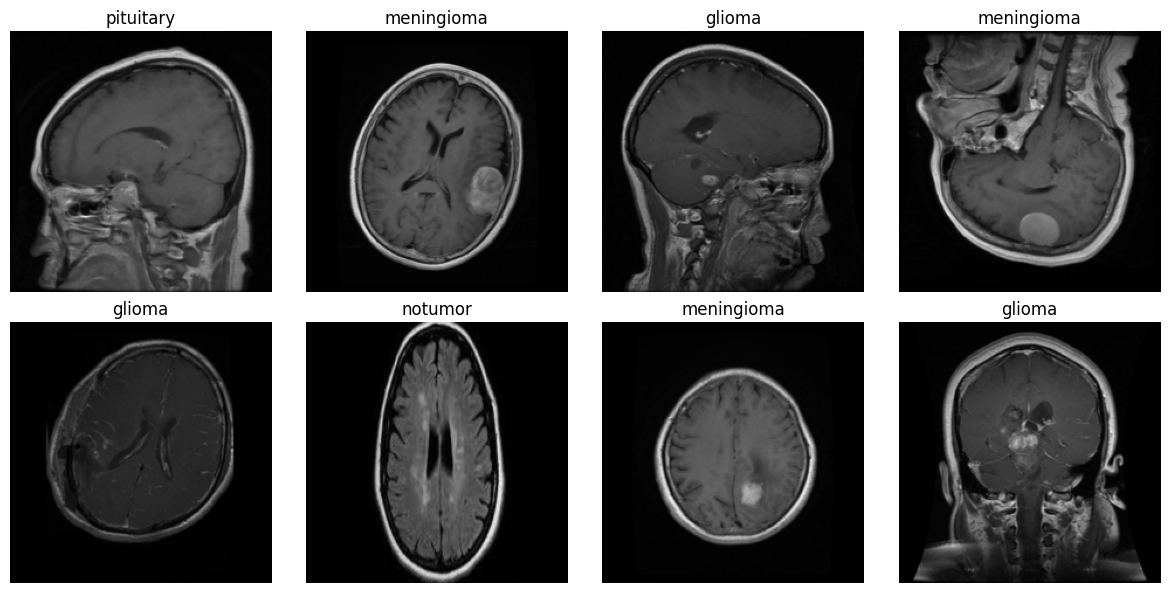

In [8]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## CNN

In [9]:
model = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


### Training

In [10]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [11]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_simplecnn.pth")

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        print(f"Best model saved to {best_model_path}")

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Val Acc: {best_val_acc:.4f}")

Epoch [1/20] Train Loss: 0.7904 | Train Acc: 0.6779 | Val Loss: 0.5252 | Val Acc: 0.7964
Best model saved to checkpoints/best_simplecnn.pth
Epoch [2/20] Train Loss: 0.4747 | Train Acc: 0.8183 | Val Loss: 0.3669 | Val Acc: 0.8571
Best model saved to checkpoints/best_simplecnn.pth
Epoch [3/20] Train Loss: 0.3350 | Train Acc: 0.8746 | Val Loss: 0.3179 | Val Acc: 0.8830
Best model saved to checkpoints/best_simplecnn.pth
Epoch [4/20] Train Loss: 0.2432 | Train Acc: 0.9087 | Val Loss: 0.2531 | Val Acc: 0.9089
Best model saved to checkpoints/best_simplecnn.pth
Epoch [5/20] Train Loss: 0.1772 | Train Acc: 0.9346 | Val Loss: 0.2468 | Val Acc: 0.9098
Best model saved to checkpoints/best_simplecnn.pth
Epoch [6/20] Train Loss: 0.1491 | Train Acc: 0.9478 | Val Loss: 0.2127 | Val Acc: 0.9330
Best model saved to checkpoints/best_simplecnn.pth
Epoch [7/20] Train Loss: 0.1079 | Train Acc: 0.9616 | Val Loss: 0.2123 | Val Acc: 0.9295
Epoch [8/20] Train Loss: 0.0915 | Train Acc: 0.9674 | Val Loss: 0.2272 

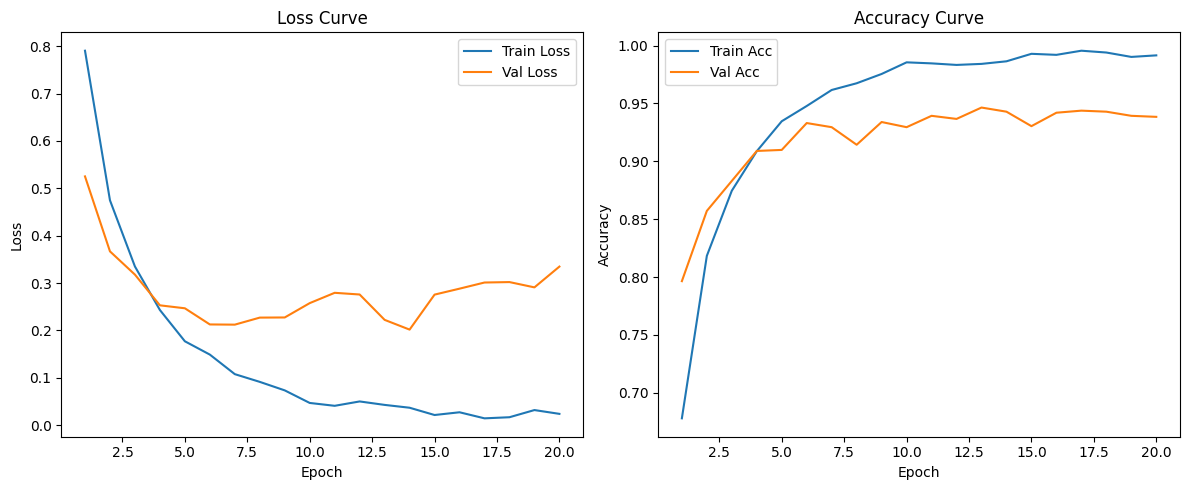

In [12]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")

Test Loss: 0.8911
Test Acc: 0.8856


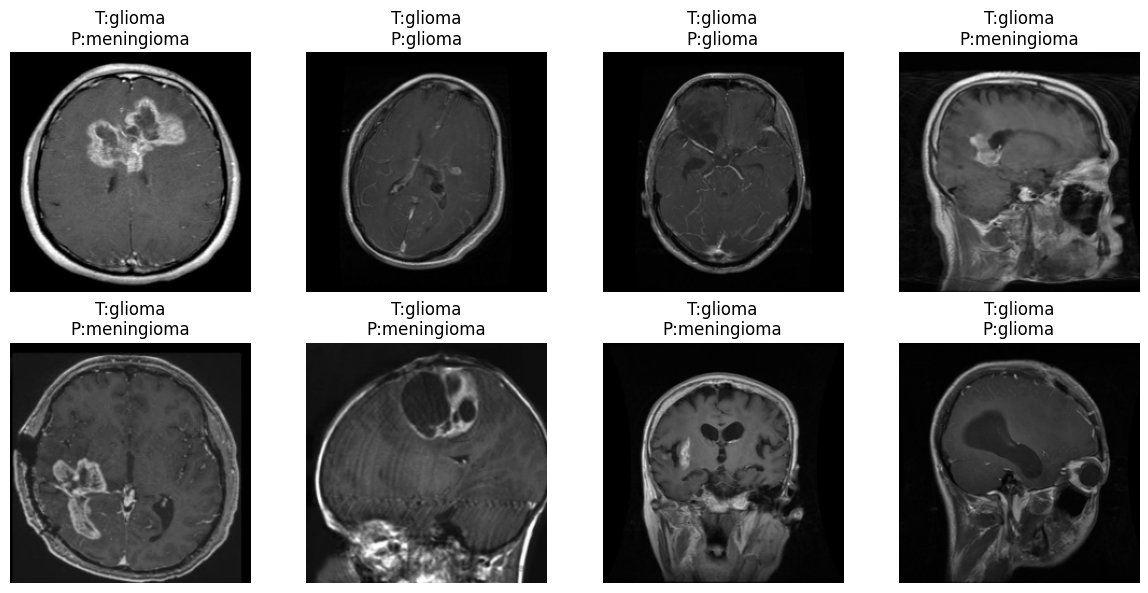

In [14]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Resnet18

In [15]:
model = get_resnet18(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Training

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [17]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_resnet18.pth")

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        print(f"Best model saved to {best_model_path}")

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Val Acc: {best_val_acc:.4f}")

Epoch [1/20] Train Loss: 0.3847 | Train Acc: 0.8627 | Val Loss: 1.2128 | Val Acc: 0.6973
Best model saved to checkpoints/best_resnet18.pth
Epoch [2/20] Train Loss: 0.2052 | Train Acc: 0.9268 | Val Loss: 0.4204 | Val Acc: 0.8420
Best model saved to checkpoints/best_resnet18.pth
Epoch [3/20] Train Loss: 0.1474 | Train Acc: 0.9473 | Val Loss: 1.3056 | Val Acc: 0.6027
Epoch [4/20] Train Loss: 0.0977 | Train Acc: 0.9650 | Val Loss: 0.1551 | Val Acc: 0.9509
Best model saved to checkpoints/best_resnet18.pth
Epoch [5/20] Train Loss: 0.0615 | Train Acc: 0.9770 | Val Loss: 0.7680 | Val Acc: 0.7982
Epoch [6/20] Train Loss: 0.0616 | Train Acc: 0.9797 | Val Loss: 0.1775 | Val Acc: 0.9464
Epoch [7/20] Train Loss: 0.0343 | Train Acc: 0.9895 | Val Loss: 0.2308 | Val Acc: 0.9286
Epoch [8/20] Train Loss: 0.0706 | Train Acc: 0.9743 | Val Loss: 0.2175 | Val Acc: 0.9259
Epoch [9/20] Train Loss: 0.0661 | Train Acc: 0.9772 | Val Loss: 0.3218 | Val Acc: 0.8893
Epoch [10/20] Train Loss: 0.0293 | Train Acc: 0.9

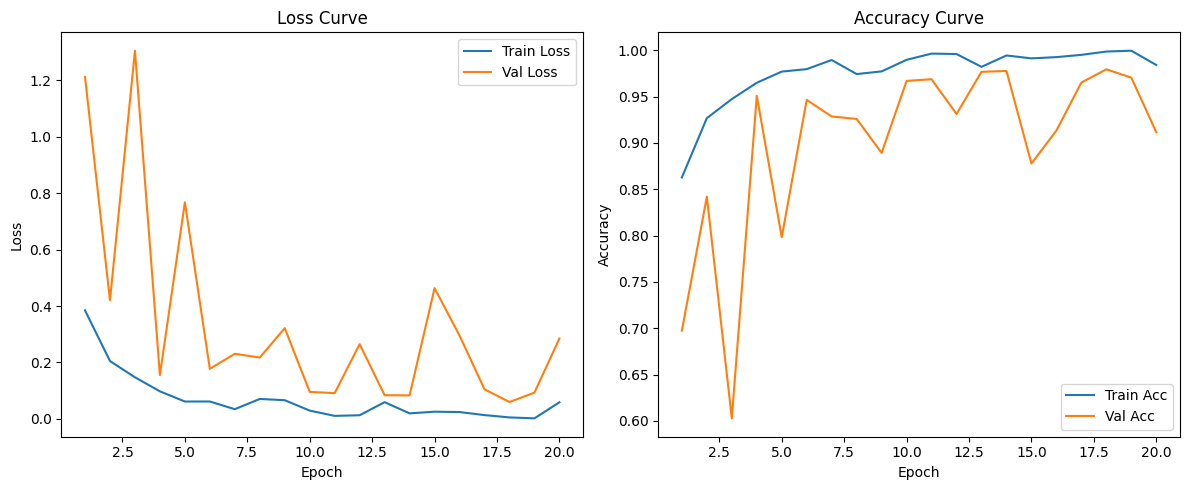

In [18]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [19]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")

Test Loss: 0.5450
Test Acc: 0.9381


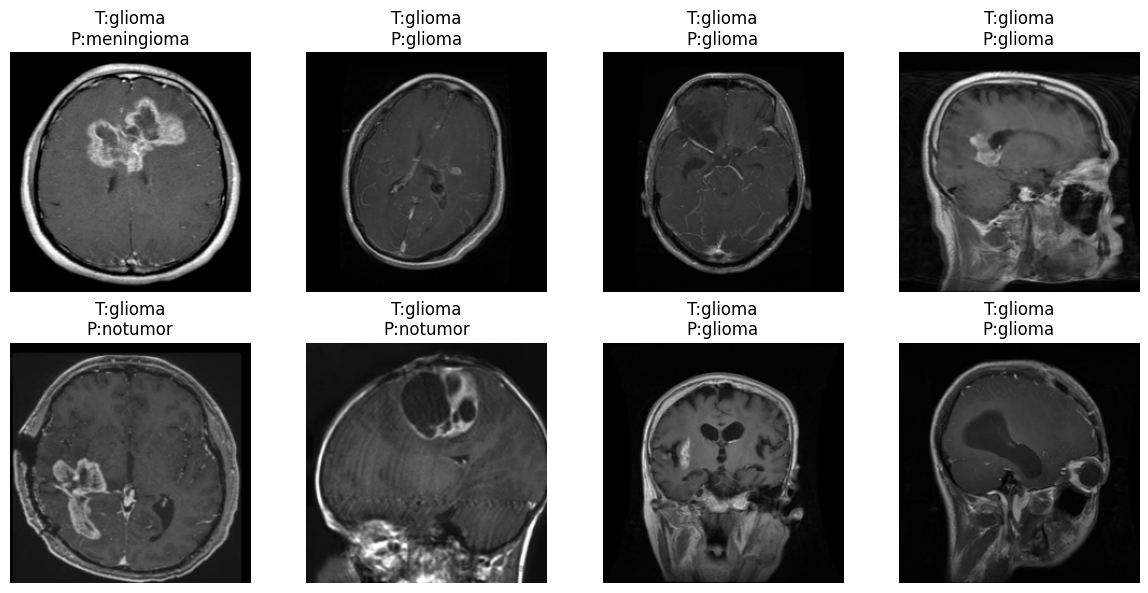

In [20]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Efficientnet

In [21]:
model = get_efficientnet_b0(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Training

In [22]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [23]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_efficientnet_b0.pth")

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        print(f"Best model saved to {best_model_path}")

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed:.2f} seconds")
print(f"Best Val Acc: {best_val_acc:.4f}")

Epoch [1/20] Train Loss: 0.3151 | Train Acc: 0.8888 | Val Loss: 0.2585 | Val Acc: 0.9098
Best model saved to checkpoints/best_efficientnet_b0.pth
Epoch [2/20] Train Loss: 0.1360 | Train Acc: 0.9585 | Val Loss: 0.1080 | Val Acc: 0.9616
Best model saved to checkpoints/best_efficientnet_b0.pth
Epoch [3/20] Train Loss: 0.0833 | Train Acc: 0.9714 | Val Loss: 0.0829 | Val Acc: 0.9750
Best model saved to checkpoints/best_efficientnet_b0.pth
Epoch [4/20] Train Loss: 0.0567 | Train Acc: 0.9804 | Val Loss: 0.0826 | Val Acc: 0.9723
Epoch [5/20] Train Loss: 0.0442 | Train Acc: 0.9875 | Val Loss: 0.1066 | Val Acc: 0.9732
Epoch [6/20] Train Loss: 0.0626 | Train Acc: 0.9817 | Val Loss: 0.1443 | Val Acc: 0.9473
Epoch [7/20] Train Loss: 0.0440 | Train Acc: 0.9857 | Val Loss: 0.1045 | Val Acc: 0.9679
Epoch [8/20] Train Loss: 0.0435 | Train Acc: 0.9864 | Val Loss: 0.1310 | Val Acc: 0.9688
Epoch [9/20] Train Loss: 0.0217 | Train Acc: 0.9924 | Val Loss: 0.0621 | Val Acc: 0.9777
Best model saved to checkpoi

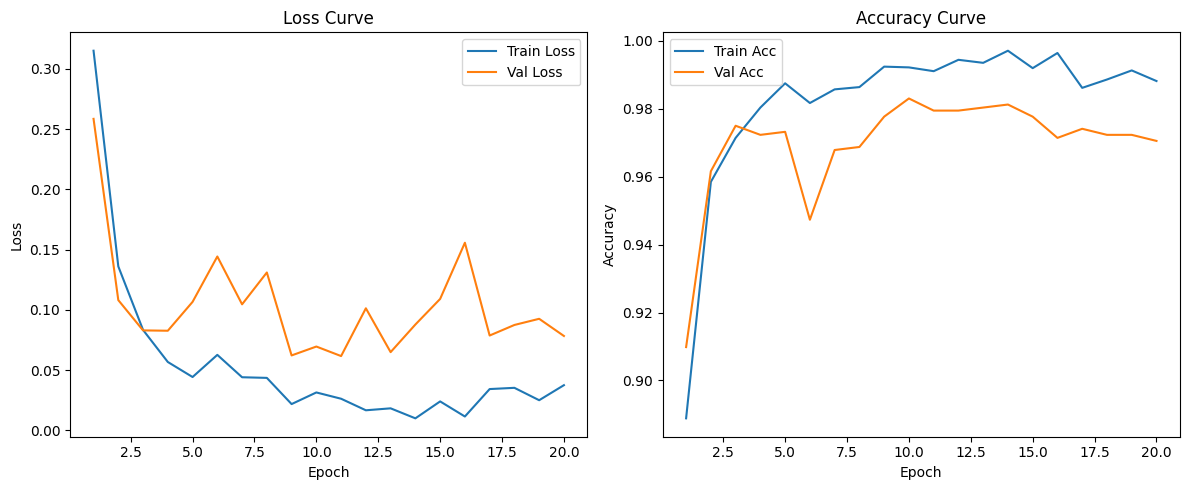

In [24]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate

In [25]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")

Test Loss: 0.4272
Test Acc: 0.9400


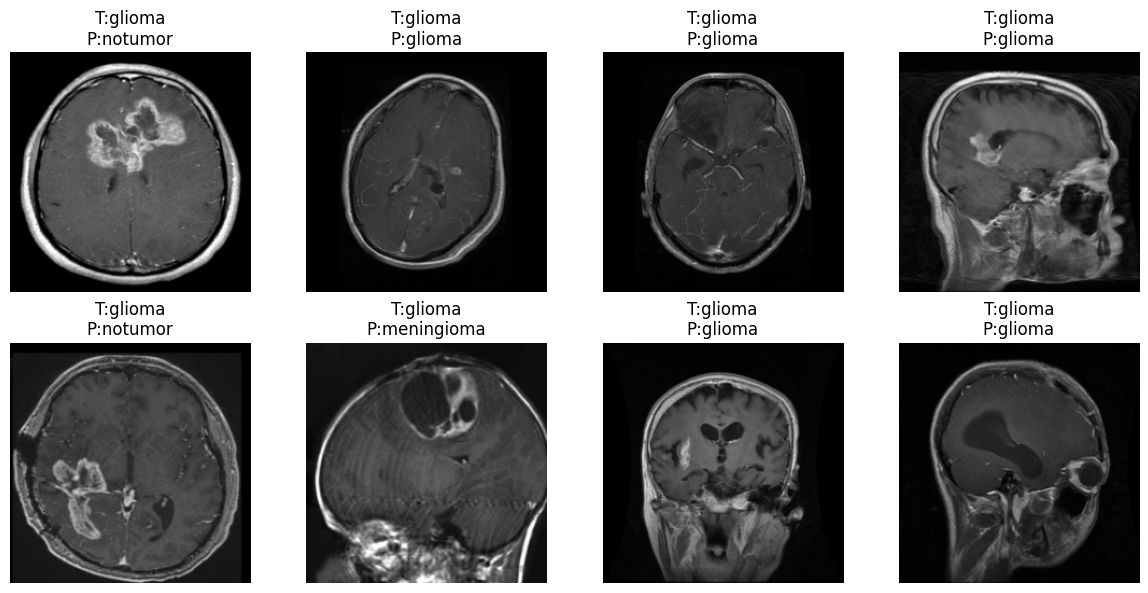

In [26]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"T:{full_train_dataset.classes[labels[i]]}\nP:{full_train_dataset.classes[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()